In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib import font_manager
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import numpy
import pandas
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import xarray as xr

In [2]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.3.1/'

In [3]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
# Add genesis year and month
    ET_DF["Genesis Year"] = ET_DF["Genesis Time"].dt.year
    ET_DF["Genesis Month"] = ET_DF["Genesis Time"].dt.month
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [6]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Split by ensemble members
def Ensemble_Split(Dataset):
    Ensemble_1 = Dataset[Dataset["Ensemble"] == 1].reset_index(drop=True)
    Ensemble_2 = Dataset[Dataset["Ensemble"] == 2].reset_index(drop=True)
    Ensemble_3 = Dataset[Dataset["Ensemble"] == 3].reset_index(drop=True)
    return (Ensemble_1, Ensemble_2, Ensemble_3)

In [8]:
# Open Dataset A files
Control_Data_A, Control_ET_A, Control_Codes = Files_Open("Control", Diri, 'DatasetA')
RCP45_Data_A, RCP45_ET_A, RCP45_Codes = Files_Open("RCP45", Diri, 'DatasetA')
RCP85_Data_A, RCP85_ET_A, RCP85_Codes = Files_Open("RCP85", Diri, 'DatasetA')

In [9]:
# Open Subset B files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, 'SubsetB')
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, 'SubsetB')
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, 'SubsetB')

In [10]:
RCP45_ET

,Code,Name,Orig Code,Ensemble,Trans Type,Peak Time,Peak SLP,Peak Lon,Peak Lat,Trop Peak Time,...,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat,Genesis Year,Genesis Month
0,TC200201,Alex,66,1,2,2002-01-13 06:00:00,973.33,-43.77,40.75,2002-01-14 06:00:00,...,2002-01-16 18:00:00,997.12,-20.50,34.25,2002-01-17 00:00:00,1001.61,-18.50,35.50,2002,1
1,TC200204,Dawn,76,1,2,2002-03-14 12:00:00,974.18,-58.07,41.52,2002-03-14 12:00:00,...,2002-03-18 00:00:00,984.01,-45.95,51.83,2002-03-18 06:00:00,987.66,-44.42,52.34,2002,3
2,TC200209,Flavia,93,1,2,2002-09-03 18:00:00,916.62,-59.07,23.47,2002-09-03 18:00:00,...,2002-09-07 06:00:00,943.24,-65.14,39.41,2002-09-08 06:00:00,983.00,-57.64,52.78,2002,8
3,TC200210,Harrison,94,1,2,2002-09-12 00:00:00,924.42,-67.65,29.01,2002-09-12 00:00:00,...,2002-09-17 06:00:00,952.37,-66.94,36.41,2002-09-20 12:00:00,959.76,-32.08,51.73,2002,9
4,TC200213,Kinen,98,1,2,2002-10-24 06:00:00,990.97,-19.94,38.93,2002-10-24 06:00:00,...,2002-10-25 06:00:00,996.31,-14.54,37.14,2002-10-25 18:00:00,999.55,-10.63,37.67,2002,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,TC209411,Geoffrey,1357,3,2,2094-11-08 18:00:00,962.96,-30.03,50.08,2094-11-05 18:00:00,...,2094-11-06 00:00:00,994.31,-55.40,37.56,2094-11-09 12:00:00,970.20,-20.27,49.55,2094,11
214,TC209501,Hazel,1364,3,2,2095-01-15 06:00:00,963.38,-43.48,47.31,2095-01-13 18:00:00,...,2095-01-14 00:00:00,978.54,-56.81,31.00,2095-01-15 12:00:00,968.11,-41.18,49.59,2095,1
215,TC209504,Joshua,1381,3,2,2095-08-25 00:00:00,924.05,-62.11,24.21,2095-08-25 00:00:00,...,2095-08-28 06:00:00,936.79,-61.82,38.62,2095-08-30 00:00:00,968.57,-52.28,51.88,2095,8
216,TC209511,Mary,1395,3,2,2095-11-29 18:00:00,969.67,-51.73,49.88,2095-11-28 00:00:00,...,2095-11-28 06:00:00,987.61,-49.98,47.78,2095-11-29 00:00:00,988.95,-45.15,54.75,2095,11


In [11]:
# Count storms based on genesis month each year
def Count_Months_Per_Year(ET_DF):
    Counts_DF = ET_DF.groupby(["Genesis Year", "Genesis Month"]).size().unstack(fill_value=0)
    Counts_DF = Counts_DF.reindex(columns=range(1, 13), fill_value=0)
    Counts_DF["Total"] = Counts_DF.sum(axis=1, numeric_only=True)
    return (Counts_DF)

In [12]:
# Count storms based on genesis month
def Count_Months(ET_DF):
    Counts_DF = Count_Months_Per_Year(ET_DF)
    Sums = numpy.array(Counts_DF.sum())
    return (Sums)

In [23]:
# Create dataframe to store months data
def Months_DF(Control_ET_A_All, RCP45_ET_A_All, RCP85_ET_A_All, Control_ET_All, RCP45_ET_All, RCP85_ET_All, Ensemble):
    Months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total']
#
# Split by ensemble member
    Control_ET_A = Ensemble_Split(Control_ET_A_All)[Ensemble]
    RCP45_ET_A = Ensemble_Split(RCP45_ET_A_All)[Ensemble]
    RCP85_ET_A = Ensemble_Split(RCP85_ET_A_All)[Ensemble]
    Control_ET = Ensemble_Split(Control_ET_All)[Ensemble]
    RCP45_ET = Ensemble_Split(RCP45_ET_All)[Ensemble]
    RCP85_ET = Ensemble_Split(RCP85_ET_All)[Ensemble]
#
# Use function to count number of storm genesis in each month for Dataset A (overall storm count)
    Control_ET_A_Months = Count_Months(Control_ET_A) / 30
    RCP45_ET_A_Months = Count_Months(RCP45_ET_A) / 31
    RCP85_ET_A_Months = Count_Months(RCP85_ET_A) / 31
# Observed Climatology of All North Atlantic TCs
    Climo_A_Months = numpy.array([6,1,1,3,32,113,145,439,709,431,122,24,2026]) / 172
    print (Control_ET_A_Months)
#
# Use function to count number of storm genesis in each month for Subset B (ET Complete Cases)
    Control_ET_B_Months = Count_Months(Control_ET) / 30
    RCP45_ET_B_Months = Count_Months(RCP45_ET) / 31
    RCP85_ET_B_Months = Count_Months(RCP85_ET) / 31
    print (Control_ET_B_Months)
#
# Calculate percentage of ET complete
    Control_ET_Percent = Control_ET_B_Months / Control_ET_A_Months
    RCP45_ET_Percent = RCP45_ET_B_Months / RCP45_ET_A_Months
    RCP85_ET_Percent = RCP85_ET_B_Months / RCP85_ET_A_Months
#
# Create dataframe
    DF = pandas.DataFrame({"Month": Months, "Climo Dataset A": Climo_A_Months, \
    "Control Dataset A": Control_ET_A_Months, "RCP4.5 Dataset A": RCP45_ET_A_Months, "RCP8.5 Dataset A": RCP85_ET_A_Months, \
    "Control Subset B": Control_ET_B_Months, "RCP4.5 Subset B": RCP45_ET_B_Months, "RCP8.5 Subset B": RCP85_ET_B_Months, \
    "Control ET Complete Rate": Control_ET_Percent, "RCP4.5 ET Complete Rate": RCP45_ET_Percent, \
    "RCP8.5 ET Complete Rate": RCP85_ET_Percent})
    DF = DF.round(3)
    return (DF)

In [24]:
# Monthly climatological statistics for Ensemble 001
Months_Count_DF_001 = Months_DF(Control_ET_A, RCP45_ET_A, RCP85_ET_A, Control_ET, RCP45_ET, RCP85_ET, 0)
Months_Count_DF_001

[0.3        0.2        0.26666667 0.3        0.2        0.2
 0.16666667 1.26666667 2.23333333 1.1        0.36666667 0.2
 6.8       ]
[0.03333333 0.06666667 0.06666667 0.03333333 0.         0.1
 0.13333333 0.66666667 1.2        0.63333333 0.2        0.06666667
 3.2       ]


,Month,Climo Dataset A,Control Dataset A,RCP4.5 Dataset A,RCP8.5 Dataset A,Control Subset B,RCP4.5 Subset B,RCP8.5 Subset B,Control ET Complete Rate,RCP4.5 ET Complete Rate,RCP8.5 ET Complete Rate
0,Jan,0.035,0.300,0.194,0.194,0.033,0.065,0.097,0.111,0.333,0.500
1,Feb,0.006,0.200,0.323,0.258,0.067,0.161,0.129,0.333,0.500,0.500
2,Mar,0.006,0.267,0.129,0.194,0.067,0.032,0.065,0.250,0.250,0.333
3,Apr,0.017,0.300,0.387,0.161,0.033,0.129,0.065,0.111,0.333,0.400
4,May,0.186,0.200,0.129,0.065,0.000,0.065,0.065,0.000,0.500,1.000
5,Jun,0.657,0.200,0.194,0.161,0.100,0.032,0.065,0.500,0.167,0.400
6,Jul,0.843,0.167,0.129,0.065,0.133,0.065,0.032,0.800,0.500,0.500
7,Aug,2.552,1.267,0.677,0.452,0.667,0.452,0.226,0.526,0.667,0.500
8,Sep,4.122,2.233,0.806,0.774,1.200,0.516,0.419,0.537,0.640,0.542
9,Oct,2.506,1.100,0.710,0.419,0.633,0.548,0.258,0.576,0.773,0.615


In [25]:
# Monthly climatological statistics for Ensemble 002
Months_Count_DF_002 = Months_DF(Control_ET_A, RCP45_ET_A, RCP85_ET_A, Control_ET, RCP45_ET, RCP85_ET, 1)
Months_Count_DF_002

[0.26666667 0.16666667 0.2        0.3        0.33333333 0.16666667
 0.43333333 1.26666667 1.66666667 0.93333333 0.5        0.26666667
 6.5       ]
[0.13333333 0.03333333 0.1        0.1        0.2        0.03333333
 0.23333333 0.73333333 0.76666667 0.56666667 0.2        0.16666667
 3.26666667]


,Month,Climo Dataset A,Control Dataset A,RCP4.5 Dataset A,RCP8.5 Dataset A,Control Subset B,RCP4.5 Subset B,RCP8.5 Subset B,Control ET Complete Rate,RCP4.5 ET Complete Rate,RCP8.5 ET Complete Rate
0,Jan,0.035,0.267,0.161,0.290,0.133,0.065,0.097,0.500,0.400,0.333
1,Feb,0.006,0.167,0.129,0.226,0.033,0.065,0.097,0.200,0.500,0.429
2,Mar,0.006,0.200,0.226,0.323,0.100,0.129,0.161,0.500,0.571,0.500
3,Apr,0.017,0.300,0.129,0.226,0.100,0.032,0.097,0.333,0.250,0.429
4,May,0.186,0.333,0.161,0.323,0.200,0.032,0.097,0.600,0.200,0.300
5,Jun,0.657,0.167,0.161,0.290,0.033,0.097,0.194,0.200,0.600,0.667
6,Jul,0.843,0.433,0.097,0.097,0.233,0.032,0.065,0.538,0.333,0.667
7,Aug,2.552,1.267,0.645,0.516,0.733,0.484,0.290,0.579,0.750,0.562
8,Sep,4.122,1.667,0.806,0.742,0.767,0.387,0.516,0.460,0.480,0.696
9,Oct,2.506,0.933,0.871,0.613,0.567,0.452,0.484,0.607,0.519,0.789


In [26]:
# Monthly climatological statistics for Ensemble 003
Months_Count_DF_003 = Months_DF(Control_ET_A, RCP45_ET_A, RCP85_ET_A, Control_ET, RCP45_ET, RCP85_ET, 2)
Months_Count_DF_003

[0.26666667 0.13333333 0.3        0.23333333 0.06666667 0.26666667
 0.26666667 1.         1.73333333 1.         0.56666667 0.2
 6.03333333]
[0.03333333 0.1        0.16666667 0.16666667 0.03333333 0.16666667
 0.1        0.53333333 1.2        0.53333333 0.26666667 0.06666667
 3.36666667]


,Month,Climo Dataset A,Control Dataset A,RCP4.5 Dataset A,RCP8.5 Dataset A,Control Subset B,RCP4.5 Subset B,RCP8.5 Subset B,Control ET Complete Rate,RCP4.5 ET Complete Rate,RCP8.5 ET Complete Rate
0,Jan,0.035,0.267,0.258,0.129,0.033,0.129,0.065,0.125,0.500,0.500
1,Feb,0.006,0.133,0.194,0.129,0.100,0.032,0.065,0.750,0.167,0.500
2,Mar,0.006,0.300,0.258,0.161,0.167,0.032,0.097,0.556,0.125,0.600
3,Apr,0.017,0.233,0.194,0.065,0.167,0.065,0.065,0.714,0.333,1.000
4,May,0.186,0.067,0.129,0.290,0.033,0.065,0.129,0.500,0.500,0.444
5,Jun,0.657,0.267,0.097,0.161,0.167,0.097,0.129,0.625,1.000,0.800
6,Jul,0.843,0.267,0.097,0.065,0.100,0.000,0.000,0.375,0.000,0.000
7,Aug,2.552,1.000,0.677,0.516,0.533,0.484,0.419,0.533,0.714,0.812
8,Sep,4.122,1.733,1.000,0.742,1.200,0.581,0.484,0.692,0.581,0.652
9,Oct,2.506,1.000,0.774,0.613,0.533,0.387,0.516,0.533,0.500,0.842


In [27]:
# Create function to plot monthly frequency histograms
def Plot_Months(DF, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,12))
    Months = Create_Bins(1,12,1)
#
# Plot monthly frequency of tropical cyclone genesis climatology VS control
    Axis = Fig.add_subplot(2,2,1)
    Width = 0.25
    pyplot.bar(Months-Width/2, DF["Climo Dataset A"][:12], Width, color='blue', label="Climatology")
    pyplot.bar(Months+Width/2, DF["Control Dataset A"][:12], Width, color='limegreen', label="Control")
    Plot_Month_Formatting(Axis, 0, "Frequency (Per Year)", 0, 5, 0.5, "Monthly Frequency of Tropical Cyclone Genesis")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly frequency of tropical cyclone genesis for each scenario
    Axis = Fig.add_subplot(2,2,2)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control Dataset A"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 Dataset A"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 Dataset A"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 1, "Frequency (Per Year)", 0, 2, 0.2, "Monthly Frequency of Tropical Cyclone Genesis")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly frequency of complete ET for each scenario
    Axis = Fig.add_subplot(2,2,3)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control Subset B"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 Subset B"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 Subset B"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 2, "Frequency (Per Year)", 0, 1, 0.1, "Monthly Frequency of Complete Extratropical Transitions")
    pyplot.legend(loc=1, fontsize=15)
#
# Plot monthly ET completion rate for each scenario
    Axis = Fig.add_subplot(2,2,4)
    Width = 0.25
    pyplot.bar(Months-Width, DF["Control ET Complete Rate"][:12], Width, color='limegreen', label="Control")
    pyplot.bar(Months, DF["RCP4.5 ET Complete Rate"][:12], Width, color='darkorange', label="RCP4.5")
    pyplot.bar(Months+Width, DF["RCP8.5 ET Complete Rate"][:12], Width, color='red', label="RCP8.5")
    Plot_Month_Formatting(Axis, 3, "ET Completion Rate", 0, 1, 0.1, "Monthly Extratropical Transitions Completion Rate")
    pyplot.legend(loc=1, fontsize=15)
#
# Save Fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [28]:
# Formatting
def Plot_Month_Formatting(Axis, Plot, y_Label, Dens_Min, Dens_Max, Dens_Width, Title):
# Ticks and lims
    pyplot.xticks(Create_Bins(1,12,1))
    pyplot.xlim(0.5,12.5)
    pyplot.yticks(Create_Bins(Dens_Min, Dens_Max, Dens_Width))
    pyplot.ylim(Dens_Min, Dens_Max)
#
# Labels and title
    pyplot.ylabel(y_Label, fontsize=16)
    pyplot.xlabel("Month", fontsize=16)
    pyplot.title(Title, fontsize=18)
    Letter_Label(Axis, Plot)
#
# Gridlines
    pyplot.grid(linewidth=0.3, color='silver', linestyle='-')

In [29]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    Axis.text(0.05, 0.95, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

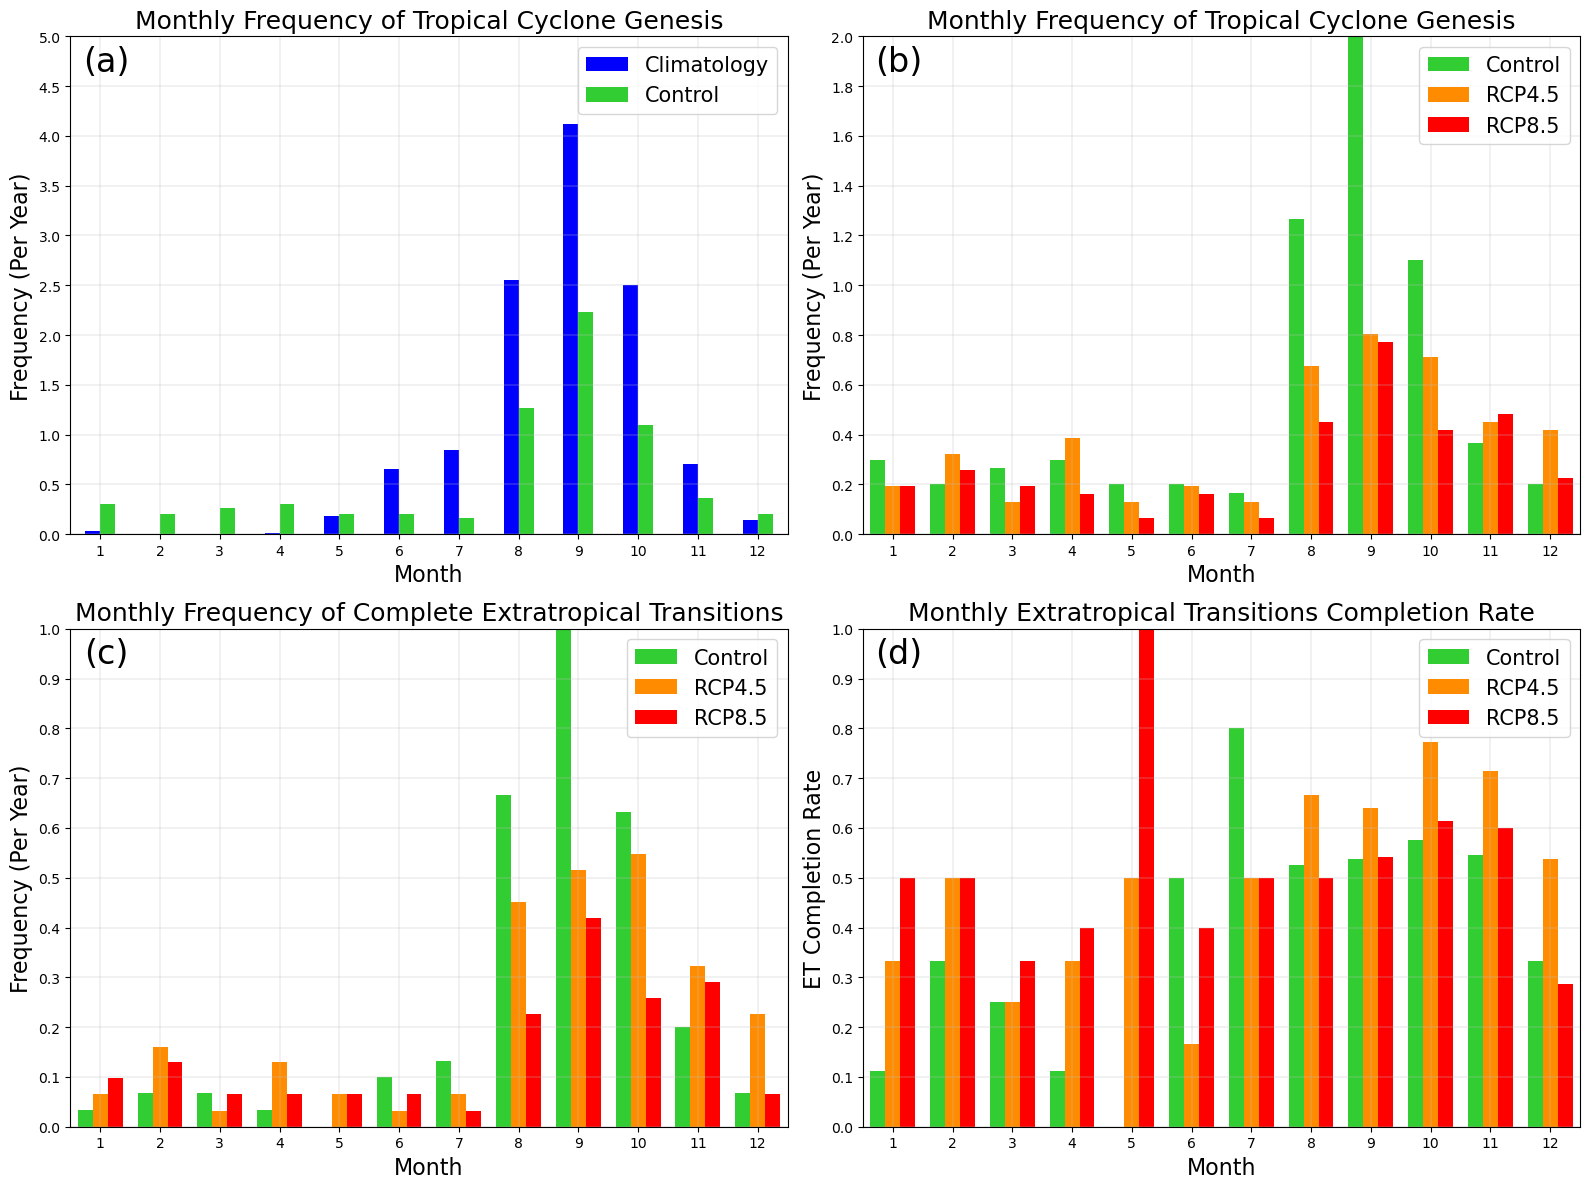

In [30]:
# Plot monthly frequency histogram for Ensemble 001
Plot_Months(Months_Count_DF_001, False, 'Months_Histogram_001.png')

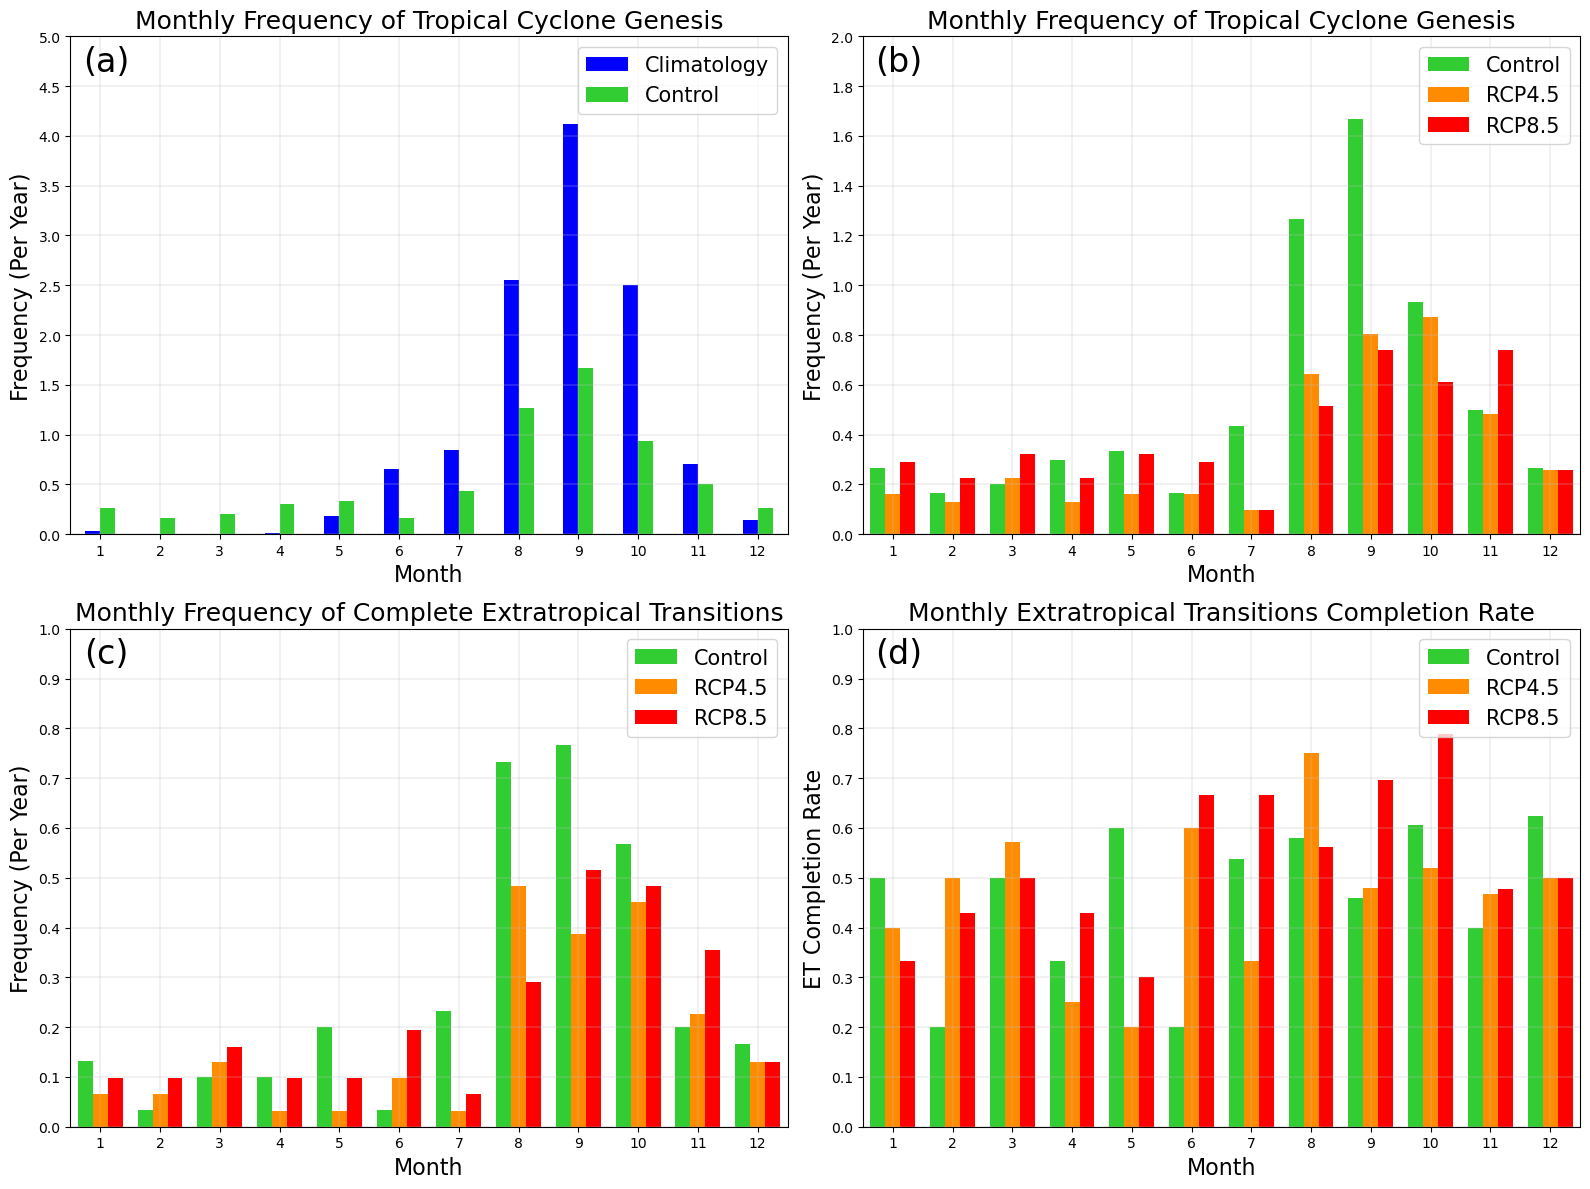

In [31]:
# Plot monthly frequency histogram for Ensemble 002
Plot_Months(Months_Count_DF_002, False, 'Months_Histogram_002.png')

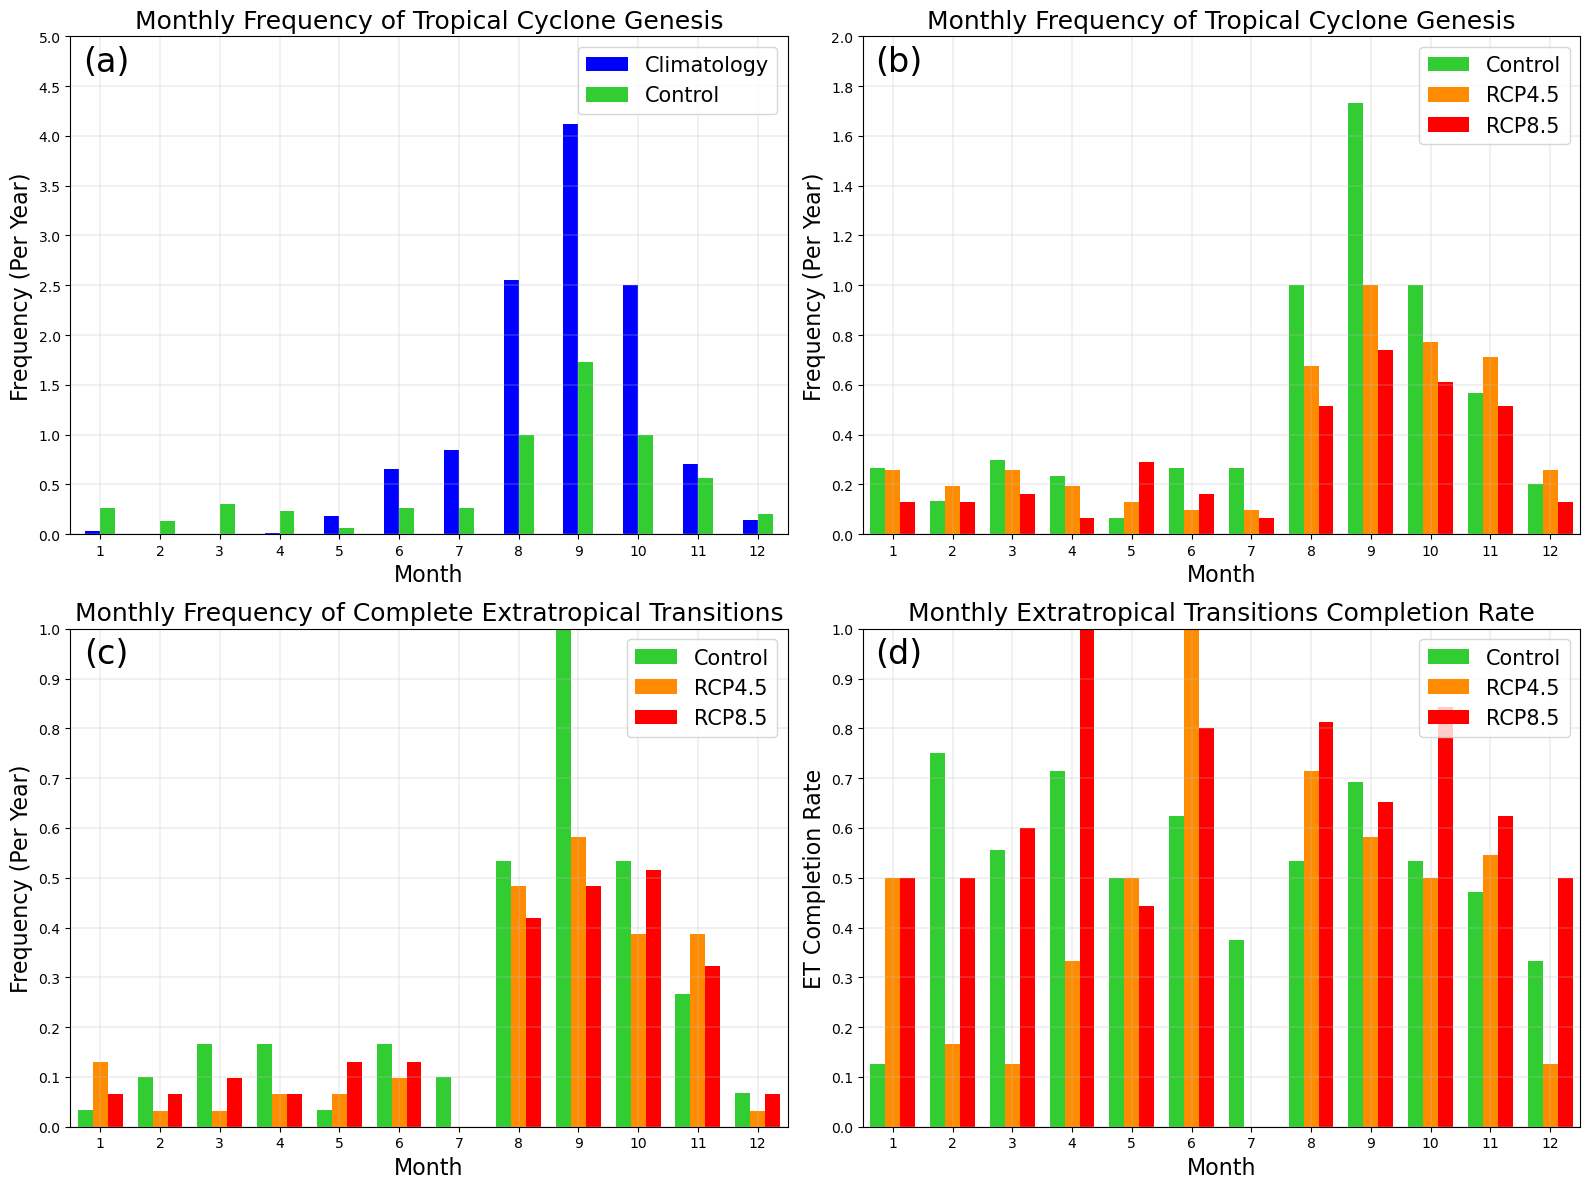

In [32]:
# Plot monthly frequency histogram for Ensemble 003
Plot_Months(Months_Count_DF_003, False, 'Months_Histogram_003.png')